In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

In [ ]:
train_data=pd.read_csv('old_dataset.csv')
test_data=pd.read_csv('new_dataset.csv')

In [ ]:
train_data.drop('Number',axis=1,inplace=True)
test_data.drop('Number',axis=1,inplace=True)

In [ ]:
train_data

,ml1,dl1,ml2,dl2,ml3,dl3,ml4,dl4,ml5,dl5,Patient Diagnosis
0,2.1,1.2,1.7,2.1,1.3,1.1,1.2,0.0,0.8,1.1,Generalised Periodontitis Stage 2 Grade B
1,3.6,2.2,2.5,0.0,1.3,0.0,1.3,0.0,1.3,0.0,Generalised Periodontitis Stage 2 Grade B
2,1.3,1.7,1.3,0.8,1.0,0.9,0.9,1.3,0.0,0.0,Healthy \n ...
3,1.6,1.3,1.4,1.4,1.3,1.0,0.0,0.0,0.0,0.0,Healthy \n ...
4,0.0,2.3,0.0,2.3,0.0,2.3,0.0,2.3,0.0,2.3,Healthy
...,...,...,...,...,...,...,...,...,...,...,...
392,2.2,1.5,1.1,0.0,0.5,0.0,0.3,1.2,0.0,1.3,Healthy \n ...
393,1.7,0.0,1.7,0.0,1.7,0.0,1.7,0.0,1.7,0.0,Healthy \n ...
394,3.6,0.0,2.3,2.1,2.3,0.9,2.0,1.7,0.0,2.3,Healthy \n ...
395,1.7,0.8,1.6,0.8,1.4,1.5,1.3,0.0,1.2,0.0,Healthy


In [ ]:
#Converting the values into Periodontitis or Healthy
#Periodontitis
maskp = train_data['Patient Diagnosis'].str.contains('periodontitis', na=False)
train_data.loc[maskp, 'Patient Diagnosis'] = 'Periodontitis'
maskP = train_data['Patient Diagnosis'].str.contains('Periodontitis', na=False)
train_data.loc[maskP, 'Patient Diagnosis'] = 'Periodontitis'
maskPG = train_data['Patient Diagnosis'].str.contains('Generalised', na=False)
train_data.loc[maskPG, 'Patient Diagnosis'] = 'Periodontitis'
maskPL = train_data['Patient Diagnosis'].str.contains('Localised', na=False)
train_data.loc[maskPL, 'Patient Diagnosis'] = 'Periodontitis'
#Healthy
maskh = train_data['Patient Diagnosis'].str.contains('gingivitis', na=False)
train_data.loc[maskh, 'Patient Diagnosis'] = 'Healthy'
maskhg = train_data['Patient Diagnosis'].str.contains('Gingivitis', na=False)
train_data.loc[maskhg, 'Patient Diagnosis'] = 'Healthy'
maskH = train_data['Patient Diagnosis'].str.contains('Healthy', na=False)
train_data.loc[maskH, 'Patient Diagnosis'] = 'Healthy'
print(train_data)

     ml1  dl1  ml2  dl2  ml3  dl3  ml4  dl4  ml5  dl5 Patient Diagnosis
0    2.1  1.2  1.7  2.1  1.3  1.1  1.2  0.0  0.8  1.1     Periodontitis
1    3.6  2.2  2.5  0.0  1.3  0.0  1.3  0.0  1.3  0.0     Periodontitis
2    1.3  1.7  1.3  0.8  1.0  0.9  0.9  1.3  0.0  0.0           Healthy
3    1.6  1.3  1.4  1.4  1.3  1.0  0.0  0.0  0.0  0.0           Healthy
4    0.0  2.3  0.0  2.3  0.0  2.3  0.0  2.3  0.0  2.3           Healthy
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...               ...
392  2.2  1.5  1.1  0.0  0.5  0.0  0.3  1.2  0.0  1.3           Healthy
393  1.7  0.0  1.7  0.0  1.7  0.0  1.7  0.0  1.7  0.0           Healthy
394  3.6  0.0  2.3  2.1  2.3  0.9  2.0  1.7  0.0  2.3           Healthy
395  1.7  0.8  1.6  0.8  1.4  1.5  1.3  0.0  1.2  0.0           Healthy
396  1.3  1.2  1.3  1.2  1.2  1.3  0.7  1.5  0.0  1.4           Healthy

[397 rows x 11 columns]


In [ ]:
#Converting the values into Periodontitis or Healthy
#Periodontitis
maskp = test_data['Patient Diagnosis'].str.contains('periodontitis', na=False)
test_data.loc[maskp, 'Patient Diagnosis'] = 'Periodontitis'
maskP = test_data['Patient Diagnosis'].str.contains('Periodontitis', na=False)
test_data.loc[maskP, 'Patient Diagnosis'] = 'Periodontitis'
maskPG = test_data['Patient Diagnosis'].str.contains('Generalised', na=False)
test_data.loc[maskPG, 'Patient Diagnosis'] = 'Periodontitis'
maskPL = test_data['Patient Diagnosis'].str.contains('Localised', na=False)
test_data.loc[maskPL, 'Patient Diagnosis'] = 'Periodontitis'
#Healthy
maskh = test_data['Patient Diagnosis'].str.contains('gingivitis', na=False)
test_data.loc[maskh, 'Patient Diagnosis'] = 'Healthy'
maskhg = test_data['Patient Diagnosis'].str.contains('Gingivitis', na=False)
test_data.loc[maskhg, 'Patient Diagnosis'] = 'Healthy'
maskH = test_data['Patient Diagnosis'].str.contains('Healthy', na=False)
test_data.loc[maskH, 'Patient Diagnosis'] = 'Healthy'
print(test_data)

      ml1  dl1  ml2  dl2  ml3  dl3  ml4  dl4  ml5  dl5 Patient Diagnosis
0     8.6  5.3  8.3  4.9  4.6  0.0  4.6  0.0  4.6  0.0     Periodontitis
1     6.5  6.7  4.0  0.0  4.0  0.0  4.0  0.0  4.0  0.0     Periodontitis
2     3.7  0.0  1.9  1.9  1.7  1.4  0.7  0.0  0.7  0.0     Periodontitis
3     3.5  3.3  3.1  0.0  0.8  0.9  0.8  0.9  0.8  0.9     Periodontitis
4     2.4  2.2  2.0  2.6  0.0  2.2  0.0  2.2  0.0  2.2     Periodontitis
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...               ...
1291  1.1  0.0  1.1  0.0  1.1  0.0  1.1  0.0  1.1  0.0     Periodontitis
1292  2.3  0.7  2.1  0.7  1.8  0.0  1.7  1.5  1.4  1.9     Periodontitis
1293  1.5  1.1  0.7  0.0  0.7  0.0  0.7  0.0  0.7  0.0           Healthy
1294  1.4  1.3  1.3  1.2  1.1  0.0  0.9  1.4  0.8  1.2           Healthy
1295  1.5  1.4  1.0  1.3  1.0  0.0  0.9  0.9  0.7  1.4           Healthy

[1296 rows x 11 columns]


In [ ]:
test_data

,ml1,dl1,ml2,dl2,ml3,dl3,ml4,dl4,ml5,dl5,Patient Diagnosis
0,8.6,5.3,8.3,4.9,4.6,0.0,4.6,0.0,4.6,0.0,Periodontitis
1,6.5,6.7,4.0,0.0,4.0,0.0,4.0,0.0,4.0,0.0,Periodontitis
2,3.7,0.0,1.9,1.9,1.7,1.4,0.7,0.0,0.7,0.0,Periodontitis
3,3.5,3.3,3.1,0.0,0.8,0.9,0.8,0.9,0.8,0.9,Periodontitis
4,2.4,2.2,2.0,2.6,0.0,2.2,0.0,2.2,0.0,2.2,Periodontitis
...,...,...,...,...,...,...,...,...,...,...,...
1291,1.1,0.0,1.1,0.0,1.1,0.0,1.1,0.0,1.1,0.0,Periodontitis
1292,2.3,0.7,2.1,0.7,1.8,0.0,1.7,1.5,1.4,1.9,Periodontitis
1293,1.5,1.1,0.7,0.0,0.7,0.0,0.7,0.0,0.7,0.0,Healthy
1294,1.4,1.3,1.3,1.2,1.1,0.0,0.9,1.4,0.8,1.2,Healthy


In [ ]:
#Split into features and target
featrs_tr = train_data.drop('Patient Diagnosis',axis=1)
target_tr = train_data['Patient Diagnosis']
featrs_te = test_data.drop('Patient Diagnosis',axis=1)
target_te = test_data['Patient Diagnosis']
print(featrs_tr.shape)
print(target_tr.shape)
print(featrs_te.shape)
print(target_te.shape)

(397, 10)
(397,)
(1296, 10)
(1296,)


In [ ]:
enc = LabelEncoder()
target_tr = enc.fit_transform(target_tr)
target_te = enc.fit_transform(target_te)
print(target_tr)
print(target_te)
train_data['Patient Diagnosis'] = target_tr
test_data['Patient Diagnosis'] = target_te
sc = MinMaxScaler()
featrs_tr = sc.fit_transform(featrs_tr)
featrs_te = sc.fit_transform(featrs_te)
print(featrs_tr.shape)
print(featrs_te.shape)

[1 1 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 1 0 0 1 1 1 1 1 1 0
 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 1 1 1
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 1 1 1 0 0 1 0 0 0
 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1
 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1
 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0]
[1 1 1 ... 0 0 0]
(397, 10)
(1296, 10)


In [ ]:
train_data

,ml1,dl1,ml2,dl2,ml3,dl3,ml4,dl4,ml5,dl5,Patient Diagnosis
0,2.1,1.2,1.7,2.1,1.3,1.1,1.2,0.0,0.8,1.1,1
1,3.6,2.2,2.5,0.0,1.3,0.0,1.3,0.0,1.3,0.0,1
2,1.3,1.7,1.3,0.8,1.0,0.9,0.9,1.3,0.0,0.0,0
3,1.6,1.3,1.4,1.4,1.3,1.0,0.0,0.0,0.0,0.0,0
4,0.0,2.3,0.0,2.3,0.0,2.3,0.0,2.3,0.0,2.3,0
...,...,...,...,...,...,...,...,...,...,...,...
392,2.2,1.5,1.1,0.0,0.5,0.0,0.3,1.2,0.0,1.3,0
393,1.7,0.0,1.7,0.0,1.7,0.0,1.7,0.0,1.7,0.0,0
394,3.6,0.0,2.3,2.1,2.3,0.9,2.0,1.7,0.0,2.3,0
395,1.7,0.8,1.6,0.8,1.4,1.5,1.3,0.0,1.2,0.0,0


In [ ]:
class1_tr = train_data[train_data['Patient Diagnosis'] == 1]
class0_tr = train_data[train_data['Patient Diagnosis'] == 0]
print(class1_tr)
print(class0_tr)

     ml1  dl1  ml2  dl2  ml3  dl3  ml4  dl4  ml5  dl5  Patient Diagnosis
0    2.1  1.2  1.7  2.1  1.3  1.1  1.2  0.0  0.8  1.1                  1
1    3.6  2.2  2.5  0.0  1.3  0.0  1.3  0.0  1.3  0.0                  1
6    1.4  0.0  1.3  1.0  1.3  0.9  1.0  1.2  0.9  0.7                  1
7    2.3  0.0  2.3  0.0  2.3  0.0  2.3  0.0  1.2  0.9                  1
8    2.4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0                  1
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...                ...
386  1.6  0.0  1.2  0.0  0.9  1.9  0.0  1.1  0.0  0.0                  1
387  2.5  2.0  2.2  0.0  2.0  1.8  0.0  2.3  0.0  0.0                  1
388  2.4  2.4  1.7  2.6  1.5  0.0  0.0  0.0  0.0  0.0                  1
389  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0                  1
390  3.1  0.0  2.7  2.0  2.2  1.9  2.1  2.8  1.5  0.0                  1

[252 rows x 11 columns]
     ml1  dl1  ml2  dl2  ml3  dl3  ml4  dl4  ml5  dl5  Patient Diagnosis
2    1.3  1.7  1.3  0.8  1

In [ ]:
test_data

,ml1,dl1,ml2,dl2,ml3,dl3,ml4,dl4,ml5,dl5,Patient Diagnosis
0,8.6,5.3,8.3,4.9,4.6,0.0,4.6,0.0,4.6,0.0,1
1,6.5,6.7,4.0,0.0,4.0,0.0,4.0,0.0,4.0,0.0,1
2,3.7,0.0,1.9,1.9,1.7,1.4,0.7,0.0,0.7,0.0,1
3,3.5,3.3,3.1,0.0,0.8,0.9,0.8,0.9,0.8,0.9,1
4,2.4,2.2,2.0,2.6,0.0,2.2,0.0,2.2,0.0,2.2,1
...,...,...,...,...,...,...,...,...,...,...,...
1291,1.1,0.0,1.1,0.0,1.1,0.0,1.1,0.0,1.1,0.0,1
1292,2.3,0.7,2.1,0.7,1.8,0.0,1.7,1.5,1.4,1.9,1
1293,1.5,1.1,0.7,0.0,0.7,0.0,0.7,0.0,0.7,0.0,0
1294,1.4,1.3,1.3,1.2,1.1,0.0,0.9,1.4,0.8,1.2,0


In [ ]:
class0_te = test_data[test_data['Patient Diagnosis'] == 0]
class1_te = test_data[test_data['Patient Diagnosis'] == 1]
print(class0_te.shape)
print(class1_te)

(129, 11)
      ml1  dl1  ml2  dl2  ml3  dl3  ml4  dl4  ml5  dl5  Patient Diagnosis
0     8.6  5.3  8.3  4.9  4.6  0.0  4.6  0.0  4.6  0.0                  1
1     6.5  6.7  4.0  0.0  4.0  0.0  4.0  0.0  4.0  0.0                  1
2     3.7  0.0  1.9  1.9  1.7  1.4  0.7  0.0  0.7  0.0                  1
3     3.5  3.3  3.1  0.0  0.8  0.9  0.8  0.9  0.8  0.9                  1
4     2.4  2.2  2.0  2.6  0.0  2.2  0.0  2.2  0.0  2.2                  1
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...                ...
1288  2.6  0.7  1.3  0.0  1.0  1.5  0.9  0.8  0.6  0.7                  1
1289  1.0  1.0  0.7  0.0  0.0  1.6  0.0  1.2  0.0  0.0                  1
1290  2.1  1.2  1.5  0.0  1.3  1.1  1.1  1.0  1.1  0.0                  1
1291  1.1  0.0  1.1  0.0  1.1  0.0  1.1  0.0  1.1  0.0                  1
1292  2.3  0.7  2.1  0.7  1.8  0.0  1.7  1.5  1.4  1.9                  1

[1167 rows x 11 columns]


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# Separate classes
class1_tr = train_data[train_data['Patient Diagnosis'] == 1]
class0_tr = train_data[train_data['Patient Diagnosis'] == 0]
print(class1_tr.shape)
print(class0_tr.shape)
class0_te = test_data[test_data['Patient Diagnosis'] == 0]
class1_te = test_data[test_data['Patient Diagnosis'] == 1]

def kmeans_undersampling(class1, class0):
    # Prepare the features for clustering (exclude the diagnosis column)
    features_columns = [col for col in class1.columns if col != 'Patient Diagnosis']

    # Perform K-means clustering on class1
    kmeans = KMeans(n_clusters=len(class0), random_state=42, n_init=10)
    kmeans.fit(class1[features_columns])

    # Get cluster labels
    cluster_labels = kmeans.labels_

    # Add cluster labels to class1
    class1_with_labels = class1.copy()
    class1_with_labels['cluster_label'] = cluster_labels

    # Select samples from each cluster to match class0 size
    undersampled_samples = []

    # Group by cluster and sample proportionally
    for cluster in range(len(class0)):
        cluster_data = class1_with_labels[class1_with_labels['cluster_label'] == cluster]

        # If cluster has more samples than needed, randomly sample
        if len(cluster_data) > len(class0) // len(np.unique(cluster_labels)):
            cluster_sample = cluster_data.sample(n=len(class0) // len(np.unique(cluster_labels)),
                                                  random_state=42)
        else:
            cluster_sample = cluster_data

        undersampled_samples.append(cluster_sample)

    # Combine the undersampled class1 with class0
    uclass1 = pd.concat(undersampled_samples)

    # Remove cluster label column
    uclass1 = uclass1.drop(columns=['cluster_label'])

    # Combine with class0
    balanced_dataset = pd.concat([class0, uclass1])

    print("Original class1 shape:", class1.shape)
    print("Original class0 shape:", class0.shape)
    print("Undersampled class1 shape:", uclass1.shape)
    print("Balanced dataset shape:", balanced_dataset.shape)

    return balanced_dataset, uclass1

# Perform undersampling
print("Train set")
balanced_data_train, uclass1_tr = kmeans_undersampling(class1_tr, class0_tr)
print("Test set")
balanced_data_test, uclass1_te = kmeans_undersampling(class1_te, class0_te)


(252, 11)
(145, 11)
Train set
Original class1 shape: (252, 11)
Original class0 shape: (145, 11)
Undersampled class1 shape: (145, 11)
Balanced dataset shape: (290, 11)
Test set
Original class1 shape: (1167, 11)
Original class0 shape: (129, 11)
Undersampled class1 shape: (129, 11)
Balanced dataset shape: (258, 11)


In [ ]:
class0 = balanced_data_train[balanced_data_train['Patient Diagnosis'] == 0]
class1 = balanced_data_train[balanced_data_train['Patient Diagnosis'] == 1]
class0f = class0.drop('Patient Diagnosis',axis=1)
class1f = class1.drop('Patient Diagnosis',axis=1)
class0t = class0['Patient Diagnosis']
class1t = class1['Patient Diagnosis']

# Split Healthy data
X_0_train, X_0_val, y_0_train, y_0_val = train_test_split(class0f,class0t,test_size=0.2, random_state=42
)


# Split Periodontitis data
X_1_train, X_1_val, y_1_train, y_1_val = train_test_split(class1f,class1t,test_size=0.2, random_state=42
)


# Combine splits from both classes
X_train = np.vstack([X_0_train, X_1_train])
y_train = np.hstack([y_0_train, y_1_train])


X_val = np.vstack([X_0_val, X_1_val])
y_val = np.hstack([y_0_val, y_1_val])

# Shuffle the data to ensure a mix of classes
train_indices = np.arange(X_train.shape[0])
val_indices = np.arange(X_val.shape[0])

np.random.shuffle(train_indices)
np.random.shuffle(val_indices)

X_train, y_train = X_train[train_indices], y_train[train_indices]
X_val, y_val = X_val[val_indices], y_val[val_indices]

In [ ]:
X_test = balanced_data_test.drop('Patient Diagnosis',axis=1)
y_test= balanced_data_test['Patient Diagnosis']

In [ ]:
print('Size of train set:',X_train.shape)
print('Size of test set:',X_test.shape)
print('Size of val set:',X_val.shape)

Size of train set: (232, 10)
Size of test set: (258, 10)
Size of val set: (58, 10)


#Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV,cross_val_score
from scipy.stats import randint
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score, ConfusionMatrixDisplay, classification_report

In [ ]:
# model
rf = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
from sklearn.model_selection import GridSearchCV
import joblib
# Model and cross-validation strategy
rf = RandomForestClassifier(random_state=42, class_weight={0: 2, 1: 1})
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400, 500],  # Define specific values for the grid
    'max_depth': [None, 5, 10, 15, 20]  # Include None for unlimited depth
}

# Initialize GridSearchCV
gridSearch = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',  # Specify the scoring metric (can use 'precision', 'recall', etc.)
    verbose=1,           # Increase verbosity to monitor progress
    n_jobs=-1            # Use all available processors
)

# Fit GridSearchCV to the training data
gridSearch.fit(X_train, y_train)
# Save the best model using joblib
best_model = gridSearch.best_estimator_
joblib.dump(best_model, 'best_random_forest_model.pkl')

print("Best model saved as 'best_random_forest_model.pkl'")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best model saved as 'best_random_forest_model.pkl'


In [ ]:
from tabulate import tabulate

params_dict = bestRf.get_params()
table = tabulate(params_dict.items(), headers=["Parameter", "Value"], tablefmt="fancy_grid")
print(table)



╒══════════════════════════╤══════════════╕
│ Parameter                │ Value        │
╞══════════════════════════╪══════════════╡
│ bootstrap                │ True         │
├──────────────────────────┼──────────────┤
│ ccp_alpha                │ 0.0          │
├──────────────────────────┼──────────────┤
│ class_weight             │ {0: 2, 1: 1} │
├──────────────────────────┼──────────────┤
│ criterion                │ gini         │
├──────────────────────────┼──────────────┤
│ max_depth                │              │
├──────────────────────────┼──────────────┤
│ max_features             │ sqrt         │
├──────────────────────────┼──────────────┤
│ max_leaf_nodes           │              │
├──────────────────────────┼──────────────┤
│ max_samples              │              │
├──────────────────────────┼──────────────┤
│ min_impurity_decrease    │ 0.0          │
├──────────────────────────┼──────────────┤
│ min_samples_leaf         │ 1            │
├──────────────────────────┼────

In [ ]:
# Retrieve the best model from GridSearchCV
bestRf = gridSearch.best_estimator_
print('Best hyperparameters:', gridSearch.best_params_)

Best hyperparameters: {'max_depth': None, 'n_estimators': 300}


In [ ]:
y_pred = bestRf.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
def print_rf_summary(acc, prec, recall, spec, f1, best_params, class_weights, save_path):
    print(f"""
===================================================================
Model Summary: RandomForestClassifier
===================================================================
▶ Model Type       : Random Forest
▶ Class Weights    : {class_weights}
▶ Best Parameters  : {best_params}
▶ Saved Model Path : {save_path}
===================================================================
Evaluation on Test Set
-------------------------------------------------------------------
Accuracy           : {acc:.2f}
Precision          : {prec:.2f}
Recall             : {recall:.2f}
Specificity        : {spec:.2f}
F1 Score           : {f1:.2f}
-------------------------------------------------------------------
""")

Accuracy: 0.9302325581395349
Precision: 0.9663865546218487
Recall: 0.8914728682170543
Specificity: 0.9689922480620154
F1 Score: 0.9274193548387096
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93       129
           1       0.97      0.89      0.93       129

    accuracy                           0.93       258
   macro avg       0.93      0.93      0.93       258
weighted avg       0.93      0.93      0.93       258



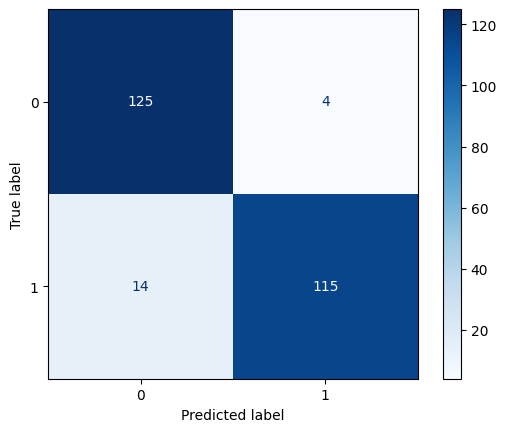

In [ ]:
# Evaluation metrics for Rf
acc_1 = accuracy_score(y_test, y_pred)
print("Accuracy:", acc_1)
prec_1 = precision_score(y_test, y_pred)
print("Precision:", prec_1)
rec_1 = recall_score(y_test, y_pred)
print("Recall:", rec_1)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)
print("Specificity:", specificity)
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
classrep = classification_report(y_test, y_pred)
print("Classification Report:\n", classrep)

import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

In [ ]:
print_rf_summary(
    acc=0.9302325581395349,
    prec=0.9663865546218487,
    recall=0.8914728682170543,
    spec=0.9689922480620154,
    f1=0.9274193548387096,
    best_params={'max_depth': None, 'n_estimators': 300},
    class_weights={0: 2, 1: 1},
    save_path='best_random_forest_model.pkl'
)



Model Summary: RandomForestClassifier
▶ Model Type       : Random Forest
▶ Class Weights    : {0: 2, 1: 1}
▶ Best Parameters  : {'max_depth': None, 'n_estimators': 300}
▶ Saved Model Path : best_random_forest_model.pkl
Evaluation on Test Set
-------------------------------------------------------------------
Accuracy           : 0.93
Precision          : 0.97
Recall             : 0.89
Specificity        : 0.97
F1 Score           : 0.93
-------------------------------------------------------------------



In [ ]:
#Validating the model using X_val and y_val
y_val_pred = bestRf.predict(X_val)
accuracyVal = accuracy_score(y_val, y_val_pred)
print("Validation Set Accuracy:", accuracyVal)

Validation Set Accuracy: 0.8275862068965517


In [ ]:
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [ ]:
# Accessing the cv_results_ attribute
cv_results = gridSearch.cv_results_

# Number of folds
n_splits = gridSearch.n_splits_
# Extract mean and std of the test scores
mean_test_scores = cv_results['mean_test_score']
std_test_scores = cv_results['std_test_score']

# Extract the test scores for each fold
split_test_scores = [cv_results[f'split{i}_test_score'] for i in range(n_splits)]

# Displaying the results
for i, (mean_score, std_score) in enumerate(zip(mean_test_scores, std_test_scores)):
    print(f"Parameter Set {i}:")
    for j in range(n_splits):
        print(f"  Fold {j+1}: {split_test_scores[j][i]}")
    print(f"  Mean CV Accuracy: {mean_score} ± {std_score}")

Parameter Set 0:
  Fold 1: 0.851063829787234
  Fold 2: 0.7446808510638298
  Fold 3: 0.9347826086956522
  Fold 4: 0.8478260869565217
  Fold 5: 0.8260869565217391
  Mean CV Accuracy: 0.8408880666049955 ± 0.06073346441466071
Parameter Set 1:
  Fold 1: 0.851063829787234
  Fold 2: 0.7446808510638298
  Fold 3: 0.9347826086956522
  Fold 4: 0.8478260869565217
  Fold 5: 0.8478260869565217
  Mean CV Accuracy: 0.8452358926919519 ± 0.060294798792804215
Parameter Set 2:
  Fold 1: 0.851063829787234
  Fold 2: 0.7446808510638298
  Fold 3: 0.9347826086956522
  Fold 4: 0.8478260869565217
  Fold 5: 0.8478260869565217
  Mean CV Accuracy: 0.8452358926919519 ± 0.060294798792804215
Parameter Set 3:
  Fold 1: 0.851063829787234
  Fold 2: 0.7446808510638298
  Fold 3: 0.9565217391304348
  Fold 4: 0.8695652173913043
  Fold 5: 0.8695652173913043
  Mean CV Accuracy: 0.8582793709528215 ± 0.06762098981838953
Parameter Set 4:
  Fold 1: 0.851063829787234
  Fold 2: 0.7446808510638298
  Fold 3: 0.9565217391304348
  Fold 